# YOGA Chatbot - Hybrid Pipeline

**YOgyakarta Guide Assistant**

Intent Classification System with 3-Stage Hybrid Pipeline

## 1. Import Libraries

In [1]:
import numpy as np
import pandas as pd
import json
import pickle
import re
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score,
    precision_recall_fscore_support
)

from Sastrawi.Stemmer.StemmerFactory import StemmerFactory

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
np.random.seed(42)

print("Libraries imported successfully")

Libraries imported successfully


## 2. Load and Preprocess Data

In [2]:
# Load intents dataset
with open('../data/raw/intents_diy_full.json', 'r', encoding='utf-8') as f:
    data = json.load(f)

intents = data['intents']

# Extract patterns and labels
patterns = []
labels = []
for intent in intents:
    for pattern in intent['patterns']:
        patterns.append(pattern)
        labels.append(intent['tag'])

df = pd.DataFrame({'pattern': patterns, 'label': labels})

print(f"Total patterns: {len(df)}")
print(f"Unique labels: {df['label'].nunique()}")

Total patterns: 2247
Unique labels: 88


In [3]:
# Initialize stemmer
stemmer = StemmerFactory().create_stemmer()

def preprocess_text(text):
    text = text.lower()
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'@\w+|#\w+', '', text)
    text = re.sub(r'[^\w\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    text = stemmer.stem(text)
    return text

# Apply preprocessing
df['processed_text'] = df['pattern'].apply(preprocess_text)

print("Preprocessing completed")
print(df[['pattern', 'processed_text', 'label']].head())

Preprocessing completed
  pattern processed_text     label
0    halo           halo  greeting
1     hai            hai  greeting
2     hey            hey  greeting
3   hello          hello  greeting
4      hi             hi  greeting


## 3. Feature Extraction - Dual TF-IDF

In [4]:
texts = df['processed_text'].values
labels_raw = df['label'].values

# Label encoding
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(labels_raw)

# Main TF-IDF (for 88-class classifier)
tfidf_main = TfidfVectorizer(
    max_features=1000,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.8,
    token_pattern=r'\b\w+\b'
)

X_tfidf_main = tfidf_main.fit_transform(texts).toarray()

# Greeting TF-IDF (for binary detector)
tfidf_greeting = TfidfVectorizer(
    max_features=500,
    ngram_range=(1, 2),
    min_df=1,
    max_df=0.9,
    token_pattern=r'\b\w+\b'
)

X_tfidf_greeting = tfidf_greeting.fit_transform(texts).toarray()

print(f"Main TF-IDF shape: {X_tfidf_main.shape}")
print(f"Greeting TF-IDF shape: {X_tfidf_greeting.shape}")
print(f"Total classes: {len(label_encoder.classes_)}")

Main TF-IDF shape: (2247, 1000)
Greeting TF-IDF shape: (2247, 500)
Total classes: 88


## 4. Train Binary GreetingDetector

In [5]:
# Define greeting intents
greeting_intents = ['goodbye', 'greeting', 'pagi', 'siang', 'sore', 'malam']
greeting_indices = [i for i, cls in enumerate(label_encoder.classes_) if cls in greeting_intents]

# Create binary labels (1=greeting, 0=non-greeting)
y_binary = np.array([1 if label in greeting_indices else 0 for label in y])

print(f"Greeting samples: {(y_binary == 1).sum()}")
print(f"Non-greeting samples: {(y_binary == 0).sum()}")

# Train-test split for binary detector
X_train_greet, X_test_greet, y_train_greet, y_test_greet = train_test_split(
    X_tfidf_greeting, y_binary,
    test_size=0.2,
    random_state=42,
    stratify=y_binary
)

# Train binary SVM
greeting_detector = SVC(
    kernel='linear',
    C=1.0,
    class_weight='balanced',
    probability=True,
    random_state=42
)

greeting_detector.fit(X_train_greet, y_train_greet)

# Evaluate
y_pred_greet = greeting_detector.predict(X_test_greet)
greet_accuracy = accuracy_score(y_test_greet, y_pred_greet)

print(f"\nBinary GreetingDetector Accuracy: {greet_accuracy*100:.2f}%")

Greeting samples: 150
Non-greeting samples: 2097

Binary GreetingDetector Accuracy: 100.00%


## 5. Train 88-Class MainClassifier

In [6]:
# Train-test split for main classifier
X_train_main, X_test_main, y_train_main, y_test_main = train_test_split(
    X_tfidf_main, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Train 88-class SVM
main_classifier = SVC(
    kernel='linear',
    C=1.0,
    random_state=42
)

main_classifier.fit(X_train_main, y_train_main)

# Baseline evaluation
y_pred_baseline = main_classifier.predict(X_test_main)
baseline_accuracy = accuracy_score(y_test_main, y_pred_baseline)

print(f"Baseline SVM Accuracy: {baseline_accuracy*100:.2f}%")

Baseline SVM Accuracy: 97.33%


## 6. Hybrid Pipeline Prediction

In [7]:
def predict_hybrid(text, confidence_threshold=0.7):
    # Preprocess
    processed = preprocess_text(text)
    
    # Stage 0: Rule filter
    word_count = len(processed.split())
    
    if word_count > 3:
        X_main = tfidf_main.transform([processed]).toarray()
        pred_idx = main_classifier.predict(X_main)[0]
        return label_encoder.classes_[pred_idx]
    
    # Stage 1: Binary GreetingDetector
    X_greeting = tfidf_greeting.transform([processed]).toarray()
    greeting_proba = greeting_detector.predict_proba(X_greeting)[0]
    confidence = greeting_proba[1]
    
    # Stage 2: Conditional classification
    X_main = tfidf_main.transform([processed]).toarray()
    
    if confidence >= confidence_threshold:
        # Pick from greeting classes only
        all_scores = main_classifier.decision_function(X_main)[0]
        greeting_scores = [(idx, all_scores[idx]) for idx in greeting_indices]
        pred_idx = max(greeting_scores, key=lambda x: x[1])[0]
        return label_encoder.classes_[pred_idx]
    else:
        # Use MainClassifier normally
        pred_idx = main_classifier.predict(X_main)[0]
        return label_encoder.classes_[pred_idx]

print("Hybrid prediction function defined")

Hybrid prediction function defined


## 7. Evaluate Hybrid Pipeline

In [8]:
# Get test texts
X_text_train, X_text_test, _, _ = train_test_split(
    texts, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Hybrid predictions
y_pred_hybrid = []
for text in X_text_test:
    pred_intent = predict_hybrid(text)
    pred_idx = np.where(label_encoder.classes_ == pred_intent)[0][0]
    y_pred_hybrid.append(pred_idx)

y_pred_hybrid = np.array(y_pred_hybrid)

# Hybrid accuracy
hybrid_accuracy = accuracy_score(y_test_main, y_pred_hybrid)

print(f"Hybrid Pipeline Accuracy: {hybrid_accuracy*100:.2f}%")
print(f"Baseline Accuracy: {baseline_accuracy*100:.2f}%")
print(f"Improvement: {(hybrid_accuracy - baseline_accuracy)*100:.2f}%")

Hybrid Pipeline Accuracy: 97.56%
Baseline Accuracy: 97.33%
Improvement: 0.22%


## 8. Greeting Intent Performance Comparison

In [9]:
# Get greeting intent metrics
precision_hybrid, recall_hybrid, f1_hybrid, support = precision_recall_fscore_support(
    y_test_main, y_pred_hybrid,
    labels=greeting_indices,
    zero_division=0
)

precision_baseline, recall_baseline, f1_baseline, _ = precision_recall_fscore_support(
    y_test_main, y_pred_baseline,
    labels=greeting_indices,
    zero_division=0
)

greeting_class_names = [label_encoder.classes_[idx] for idx in greeting_indices]

# Comparison DataFrame
comparison_df = pd.DataFrame({
    'Intent': greeting_class_names,
    'Baseline_F1': f1_baseline,
    'Hybrid_F1': f1_hybrid,
    'Improvement': f1_hybrid - f1_baseline,
    'Support': support
})

print("Greeting Intent Performance:")
print(comparison_df.to_string(index=False))

print(f"\nAverage Greeting F1:")
print(f"  Baseline: {f1_baseline.mean()*100:.2f}%")
print(f"  Hybrid: {f1_hybrid.mean()*100:.2f}%")
print(f"  Improvement: {(f1_hybrid.mean() - f1_baseline.mean())*100:.2f}%")

Greeting Intent Performance:
  Intent  Baseline_F1  Hybrid_F1  Improvement  Support
 goodbye     0.400000   0.400000     0.000000        5
greeting     0.833333   0.833333     0.000000        5
   malam     0.888889   0.888889     0.000000        5
    pagi     0.571429   0.571429     0.000000        5
   siang     1.000000   1.000000     0.000000        5
    sore     0.750000   0.888889     0.138889        5

Average Greeting F1:
  Baseline: 74.06%
  Hybrid: 76.38%
  Improvement: 2.31%


## 9. Visualizations

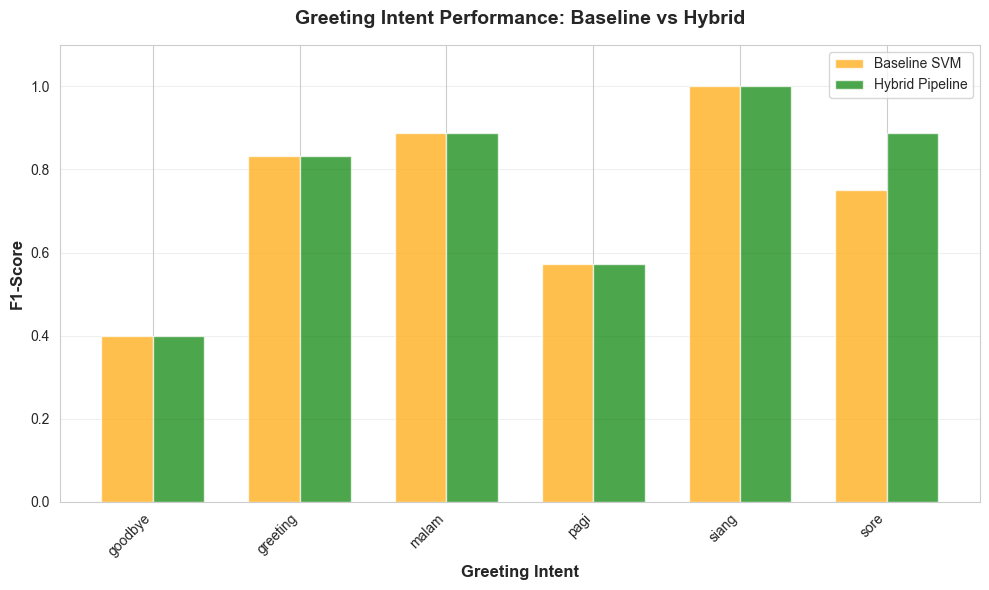

In [10]:
# Greeting F1 comparison
fig, ax = plt.subplots(figsize=(10, 6))

x = np.arange(len(greeting_class_names))
width = 0.35

ax.bar(x - width/2, comparison_df['Baseline_F1'], width, label='Baseline SVM', alpha=0.7, color='orange')
ax.bar(x + width/2, comparison_df['Hybrid_F1'], width, label='Hybrid Pipeline', alpha=0.7, color='green')

ax.set_xlabel('Greeting Intent', fontsize=12, fontweight='bold')
ax.set_ylabel('F1-Score', fontsize=12, fontweight='bold')
ax.set_title('Greeting Intent Performance: Baseline vs Hybrid', fontsize=14, fontweight='bold', pad=15)
ax.set_xticks(x)
ax.set_xticklabels(greeting_class_names, rotation=45, ha='right')
ax.legend()
ax.grid(axis='y', alpha=0.3)
ax.set_ylim([0, 1.1])

plt.tight_layout()
plt.show()

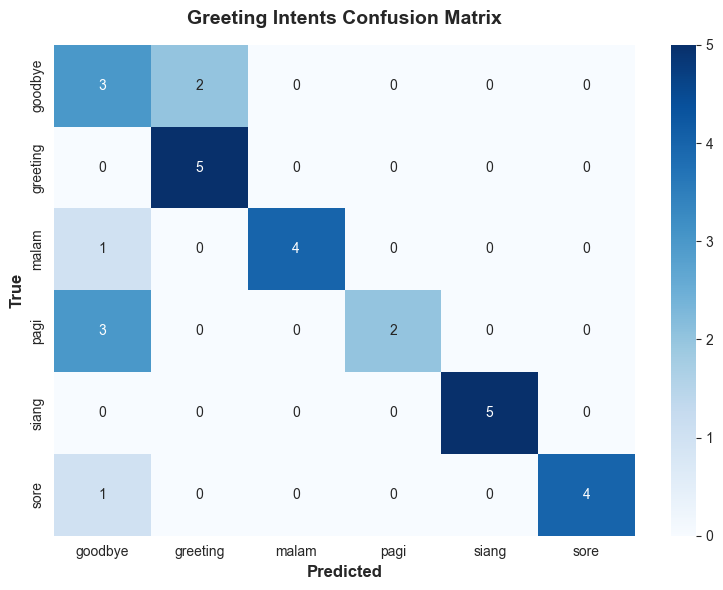

In [11]:
# Confusion matrix for greeting intents
y_test_greeting_mask = np.isin(y_test_main, greeting_indices)
y_test_greeting = y_test_main[y_test_greeting_mask]
y_pred_hybrid_greeting = y_pred_hybrid[y_test_greeting_mask]

y_test_greeting_mapped = np.array([greeting_indices.index(label) for label in y_test_greeting])
y_pred_hybrid_greeting_mapped = np.array([greeting_indices.index(label) for label in y_pred_hybrid_greeting])

cm_greeting = confusion_matrix(y_test_greeting_mapped, y_pred_hybrid_greeting_mapped)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_greeting, annot=True, fmt='d', cmap='Blues',
            xticklabels=greeting_class_names,
            yticklabels=greeting_class_names)
plt.xlabel('Predicted', fontsize=12, fontweight='bold')
plt.ylabel('True', fontsize=12, fontweight='bold')
plt.title('Greeting Intents Confusion Matrix', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

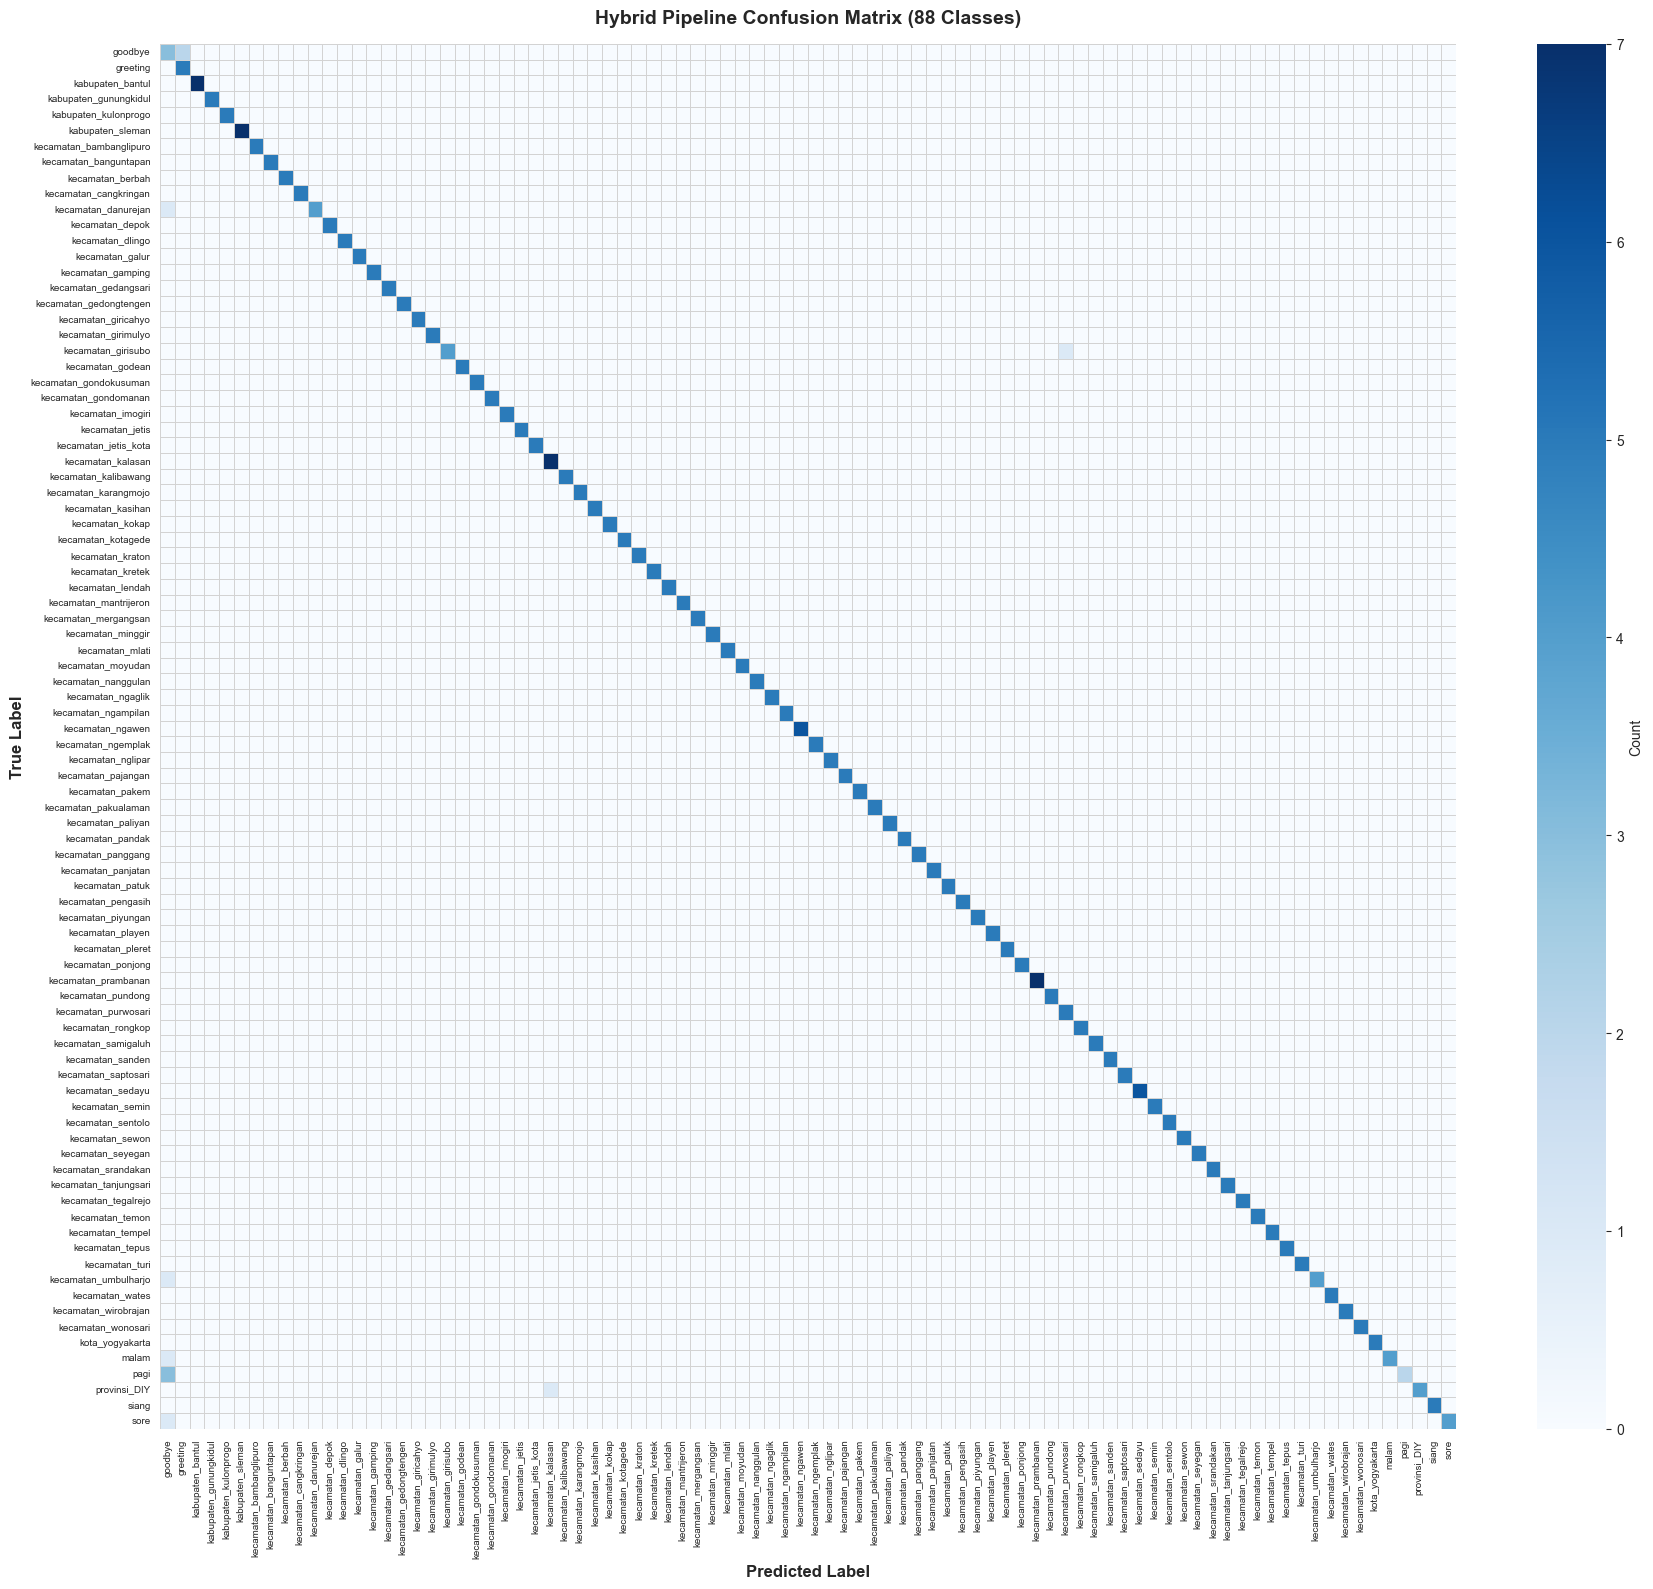

In [12]:
# Overall confusion matrix (Hybrid)
cm_hybrid = confusion_matrix(y_test_main, y_pred_hybrid)

plt.figure(figsize=(18, 16))
sns.heatmap(cm_hybrid, annot=False, cmap='Blues',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_,
            cbar_kws={'label': 'Count'},
            linewidths=0.5,
            linecolor='lightgray')
plt.xlabel('Predicted Label', fontsize=12, fontweight='bold')
plt.ylabel('True Label', fontsize=12, fontweight='bold')
plt.title('Hybrid Pipeline Confusion Matrix (88 Classes)', fontsize=14, fontweight='bold', pad=15)
plt.xticks(rotation=90, fontsize=7)
plt.yticks(rotation=0, fontsize=7)
plt.tight_layout()
plt.show()

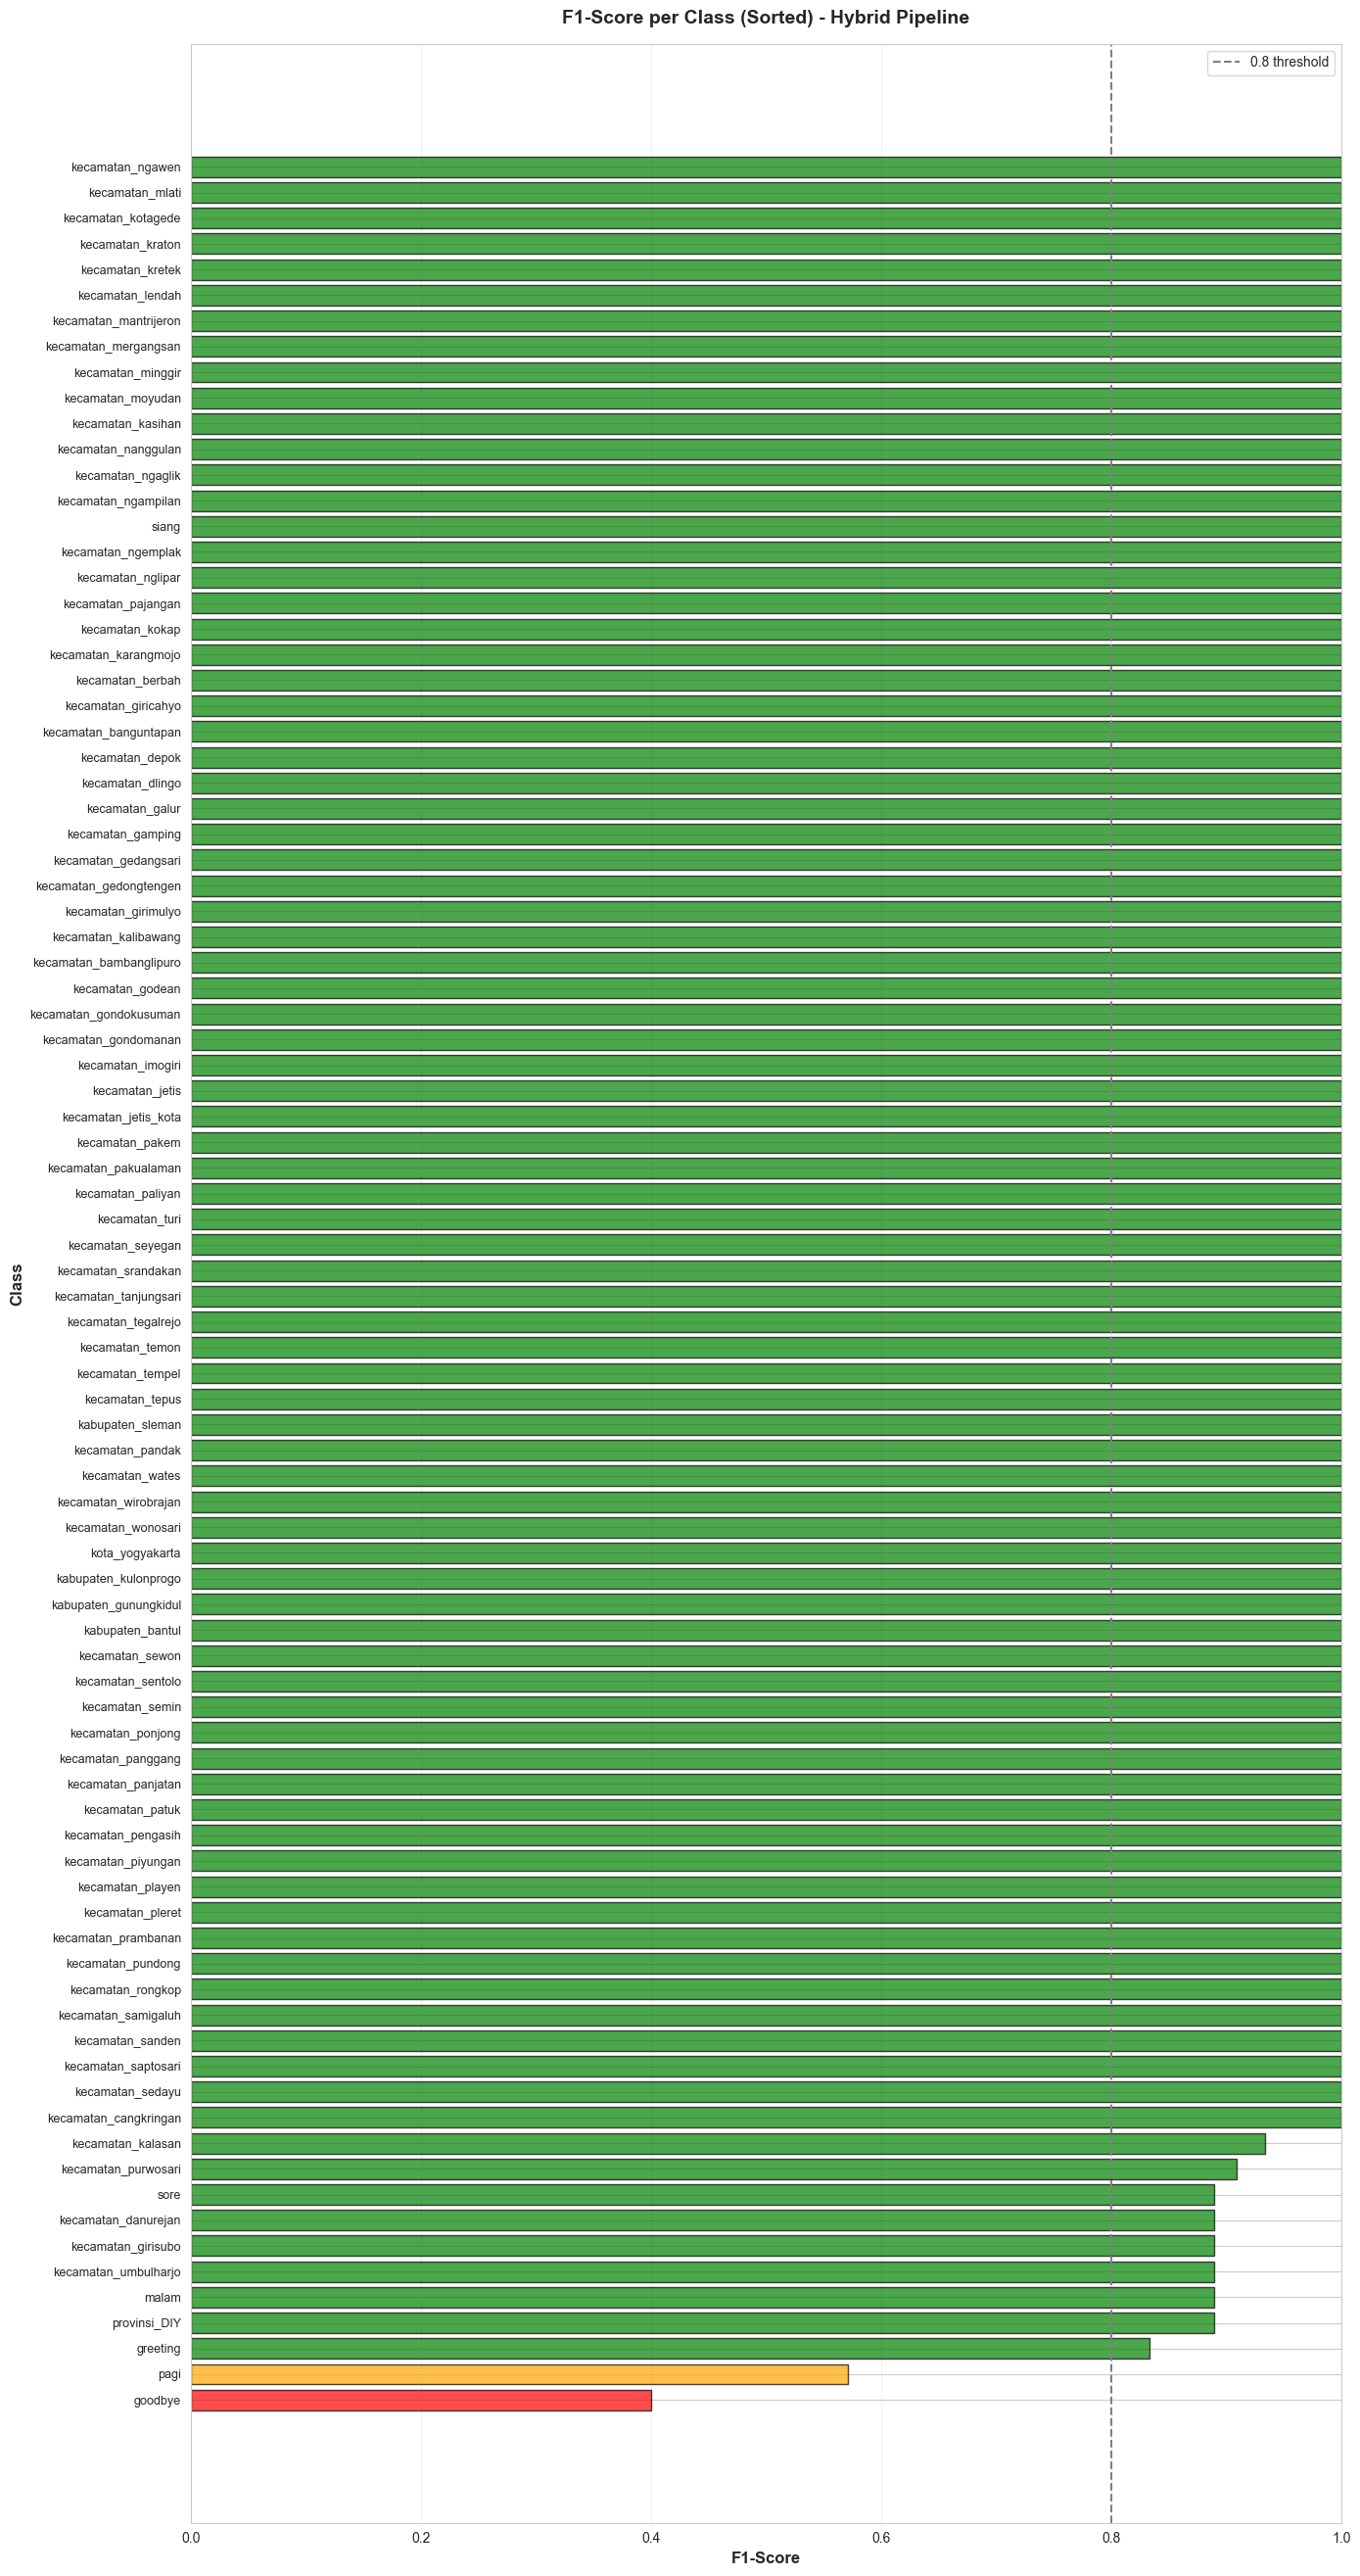

In [13]:
# Per-class F1 scores (all classes)
precision_all, recall_all, f1_all, support_all = precision_recall_fscore_support(
    y_test_main, y_pred_hybrid,
    labels=list(range(len(label_encoder.classes_))),
    zero_division=0
)

metrics_df = pd.DataFrame({
    'Class': label_encoder.classes_,
    'F1-Score': f1_all,
    'Support': support_all
})

metrics_df = metrics_df[metrics_df['Support'] > 0].sort_values('F1-Score', ascending=True)

plt.figure(figsize=(14, max(10, len(metrics_df) * 0.3)))
colors = ['green' if f >= 0.8 else 'orange' if f >= 0.5 else 'red' for f in metrics_df['F1-Score']]
plt.barh(range(len(metrics_df)), metrics_df['F1-Score'], color=colors, alpha=0.7, edgecolor='black')
plt.yticks(range(len(metrics_df)), metrics_df['Class'], fontsize=9)
plt.xlabel('F1-Score', fontsize=12, fontweight='bold')
plt.ylabel('Class', fontsize=12, fontweight='bold')
plt.title('F1-Score per Class (Sorted) - Hybrid Pipeline', fontsize=14, fontweight='bold', pad=15)
plt.axvline(x=0.8, color='gray', linestyle='--', linewidth=1.5, label='0.8 threshold')
plt.xlim([0, 1.0])
plt.grid(axis='x', alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

## 10. Overall Performance Report

In [14]:
# Classification report
report_hybrid = classification_report(
    y_test_main,
    y_pred_hybrid,
    labels=list(range(len(label_encoder.classes_))),
    target_names=label_encoder.classes_,
    digits=4,
    zero_division=0,
    output_dict=True
)

print("="*80)
print("YOGA CHATBOT - FINAL PERFORMANCE")
print("="*80)

print("\nDataset:")
print(f"  Total samples: {len(df)}")
print(f"  Total classes: {len(label_encoder.classes_)}")
print(f"  Train samples: {len(X_train_main)}")
print(f"  Test samples: {len(X_test_main)}")

print("\nArchitecture:")
print("  Stage 0: Rule-based filter (word count > 3)")
print("  Stage 1: Binary GreetingDetector (SVM)")
print("  Stage 2: Conditional MainClassifier (88-class SVM)")

print("\nFeature Extraction:")
print(f"  Main TF-IDF: {X_tfidf_main.shape[1]} features")
print(f"  Greeting TF-IDF: {X_tfidf_greeting.shape[1]} features")

print("\nPerformance:")
print(f"  Baseline Accuracy: {baseline_accuracy*100:.2f}%")
print(f"  Hybrid Accuracy: {hybrid_accuracy*100:.2f}%")
print(f"  Macro F1-Score: {report_hybrid['macro avg']['f1-score']*100:.2f}%")
print(f"  Weighted F1-Score: {report_hybrid['weighted avg']['f1-score']*100:.2f}%")

print("\nGreeting Intent Performance:")
print(f"  Baseline Avg F1: {f1_baseline.mean()*100:.2f}%")
print(f"  Hybrid Avg F1: {f1_hybrid.mean()*100:.2f}%")
print(f"  Improvement: {(f1_hybrid.mean() - f1_baseline.mean())*100:.2f}%")

print("\n" + "="*80)

YOGA CHATBOT - FINAL PERFORMANCE

Dataset:
  Total samples: 2247
  Total classes: 88
  Train samples: 1797
  Test samples: 450

Architecture:
  Stage 0: Rule-based filter (word count > 3)
  Stage 1: Binary GreetingDetector (SVM)
  Stage 2: Conditional MainClassifier (88-class SVM)

Feature Extraction:
  Main TF-IDF: 1000 features
  Greeting TF-IDF: 500 features

Performance:
  Baseline Accuracy: 97.33%
  Hybrid Accuracy: 97.56%
  Macro F1-Score: 97.71%
  Weighted F1-Score: 97.73%

Greeting Intent Performance:
  Baseline Avg F1: 74.06%
  Hybrid Avg F1: 76.38%
  Improvement: 2.31%



## 11. Interactive Chatbot Testing

In [15]:
# Load responses from intents
intent_responses = {}
for intent in intents:
    tag = intent['tag']
    responses = intent.get('responses', [])
    intent_responses[tag] = responses

def chat_with_yoga(user_input):
    """
    Interactive chatbot function
    
    Args:
        user_input: Raw user input text
    
    Returns:
        Response string
    """
    import random
    
    # Predict intent
    predicted_intent = predict_hybrid(user_input)
    
    # Get response
    if predicted_intent in intent_responses and intent_responses[predicted_intent]:
        response = random.choice(intent_responses[predicted_intent])
    else:
        response = f"Intent: {predicted_intent}"
    
    print(f"Input: {user_input}")
    print(f"Predicted Intent: {predicted_intent}")
    print(f"Response: {response}")
    print("-" * 60)
    
    return response

print("Chatbot ready! Use chat_with_yoga('your message') to test")

Chatbot ready! Use chat_with_yoga('your message') to test


In [16]:
# Test examples
test_inputs = [
    "selamat pagi",
    "halo yoga",
    "wisata di sleman",
    "tempat populer di bantul",
    "pantai di gunungkidul",
    "terima kasih"
]

print("="*80)
print("CHATBOT TEST EXAMPLES")
print("="*80)
print()

for text in test_inputs:
    chat_with_yoga(text)
    print()

CHATBOT TEST EXAMPLES

Input: selamat pagi
Predicted Intent: pagi
Response: Selamat pagi! Mau cari rekomendasi wisata di Yogyakarta?
------------------------------------------------------------

Input: halo yoga
Predicted Intent: greeting
Response: Halo! Ada yang bisa YOGA bantu?
------------------------------------------------------------

Input: wisata di sleman
Predicted Intent: kabupaten_sleman
Response: Berikut Top 5 wisata terbaik di Kabupaten Sleman:
1. Merapi Lava Tour (Jam Buka: Senin: 04.30–17.00; Selasa: 04.30–17.00; Rabu: 04.30–17.00; Kamis: 04.30–17.00; Jumat: 04.30–17.00; Sabtu: 04.30–17.00; Minggu: 04.30–17.00) (Rating: 4.9)
2. Candi Prambanan (Jam Buka: Senin: 06.00–16.30; Selasa: 06.00–16.30; Rabu: 06.00–16.30; Kamis: 06.00–16.30; Jumat: 06.00–16.30; Sabtu: 06.00–16.30; Minggu: 06.00–16.30) (Rating: 4.7)
3. Museum Ullen Sentalu (Jam Buka: Senin: Tutup; Selasa: 08.30–15.00; Rabu: 08.30–15.00; Kamis: 08.30–15.00; Jumat: 08.30–15.00; Sabtu: 08.30–15.00; Minggu: 08.30–15.0

In [ ]:
# Interactive mode (for live testing with professor)
print("="*80)
print("YOGA CHATBOT - INTERACTIVE MODE")
print("="*80)
print("\nType your message and press Enter.")
print("Type 'quit' or 'exit' to stop.\n")

while True:
    user_input = input("You: ").strip()
    
    if user_input.lower() in ['quit', 'exit', 'stop', 'keluar']:
        print("\nYOGA: Terima kasih! Sampai jumpa.")
        break
    
    if not user_input:
        continue
    
    print()
    chat_with_yoga(user_input)
    print()

YOGA CHATBOT - INTERACTIVE MODE

Type your message and press Enter.
Type 'quit' or 'exit' to stop.


YOGA: Terima kasih! Sampai jumpa.


: 